# Taller 1 — Notebook 03: Análisis, hipótesis y visualización

**MINE-4101: Ciencia de Datos Aplicada · Supervisión de contratación pública de bienes**

---

## De qué va este notebook

Aquí respondemos la pregunta del negocio: **¿a qué contratos conviene hacerles seguimiento de cerca desde que
se firman?** Trabajamos sobre los datos ya limpios (`data/processed/secop_bienes_limpio.parquet`, que salió del
notebook `02`) y ponemos a prueba, con estadística, unas pocas hipótesis sobre qué características del contrato
—las que se conocen al firmar— vienen de la mano con que el contrato se desvíe. Cubre los **Entregables 2
(Estrategia, 15%)** y **3 (Desarrollo, 40%)**, y reportamos tanto lo que sale significativo como lo que no.

> Ejecutar **después** de `01_entendimiento` y `02_limpieza`.


## 2. Estrategia de análisis (Entregable 2 — 15%)

La pregunta que nos importa es de decisión, no de curiosidad: el equipo de control interno es pequeño y no puede
vigilar todo, así que necesita saber **a qué contratos apuntar**. Por eso organizamos el análisis alrededor de
las "palancas" que se conocen al momento de firmar —valor, modalidad, tipo de contrato, sector, orden de la
entidad, destino del gasto y si el proveedor es PyME— y miramos cómo se relacionan con las desviaciones
que construimos en `02`: pedir más plazo (`adicion_plazo`) y no ejecutar el presupuesto (`subejecucion`). La
tercera que pide el negocio, cerrar sin liquidar, no se puede medir con este dataset (ver 3.4); en su lugar
analizamos qué contratos se declaran sujetos a liquidación (`no_sujeto_liquidacion`). Las tratamos por separado
porque son problemas distintos.

En vez de cruzar todo contra todo, planteamos **cinco hipótesis puntuales**, cada una atada a una palanca y con
una dirección esperada (una de ellas es una hipótesis "nula" a propósito, para mostrar qué **no** ayuda a
focalizar). Para ponerlas a prueba usamos la **U de Mann-Whitney** cuando comparamos el valor del contrato (que
está muy sesgado) entre contratos que se desvían y los que no; y la prueba **χ²** junto con la **V de Cramér**
—que mide qué tan fuerte es la relación, de 0 a 1— para las variables de categorías. Un detalle importante:
como son decenas de miles de contratos, casi cualquier diferencia sale "significativa", así que **no nos guiamos
por el p-valor sino por qué tan grande es la diferencia en la práctica** (la V de Cramér y las diferencias de
mediana). Nos quedamos con el periodo comparable (firma ≤ 2023) y, para las desviaciones que necesitan que el
contrato ya haya cerrado, solo con contratos cerrados. Al final juntamos las señales en una **tabla de segmentos
de alto riesgo**, que es el puente hacia las recomendaciones del informe ejecutivo.


## 3. Desarrollo de la estrategia (Entregable 3 — 40%)

### 3.0 Preparación: carga, bases de análisis y utilidades


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_LIMPIO = '../data/processed/secop_bienes_limpio.parquet'
RUTA_FIGS = '../figs'
ALPHA = 0.05

d = pd.read_parquet(RUTA_LIMPIO)
print(f'Dataset limpio: {d.shape[0]:,} x {d.shape[1]}')

# Bases de análisis. Trabajamos con contratos firmados hasta 2023 para comparar cohortes parecidas
# (los de 2024-2025 todavía están abiertos; ver la justificación en 01 y 02).
base_adic = d[d['periodo_analisis']].copy()                 # la adición se puede ver sin que el contrato cierre
base_sub = d[d['subejecucion'].notna()].copy()              # cerrado, en periodo y con ejecución reportada
base_liq = d[d['no_sujeto_liquidacion'].notna()].copy()              # cerrado y en periodo (marca de liquidación)
print(f'Base adición   (firma<=2023):            {len(base_adic):,}  | tasa {base_adic["adicion_plazo"].mean()*100:.1f}%')
print(f'Base subejecución (cerrado & reportado): {len(base_sub):,}  | tasa {base_sub["subejecucion"].mean()*100:.1f}%')
print(f'Base marca de liquidación (cerrado):     {len(base_liq):,}  | tasa {base_liq["no_sujeto_liquidacion"].mean()*100:.1f}%')


Dataset limpio: 196,391 x 61
Base adición   (firma<=2023):            121,644  | tasa 7.0%
Base subejecución (cerrado & reportado): 38,128  | tasa 7.9%
Base marca de liquidación (cerrado):     68,351  | tasa 59.2%


In [2]:
# --- Funciones para las pruebas de hipótesis ---
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum(); k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

def interp_v(v):
    return 'nulo' if v < 0.05 else 'pequeño' if v < 0.15 else 'moderado' if v < 0.25 else 'fuerte'

def test_categorica(df, flag, cat, min_n=200):
    '''χ² de independencia entre `cat` y `flag`, con V de Cramér y tabla de tasas por categoría.'''
    sub = df[df[flag].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    ct = pd.crosstab(sub[cat], sub[flag])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    tasas = sub.groupby(cat)[flag].agg(tasa='mean', n='size')
    tasas = tasas[tasas['n'] >= min_n].sort_values('tasa', ascending=False)
    tasas['tasa'] = (tasas['tasa'] * 100).round(1)
    return {'p': p, 'V': v, 'sig': p < ALPHA, 'efecto': interp_v(v), 'tasas': tasas}

def test_valor(df, flag, col='valor_log'):
    '''Compara el valor (en log) entre contratos que se desvían y los que no (Mann-Whitney).'''
    sub = df[df[flag].notna() & df[col].notna()].copy()
    sub[flag] = sub[flag].astype(bool)
    g1 = sub.loc[sub[flag], col]; g0 = sub.loc[~sub[flag], col]
    u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    return {'p': p, 'sig': p < ALPHA, 'med_desv': 10**g1.median(), 'med_no': 10**g0.median(),
            'n_desv': len(g1), 'n_no': len(g0)}

print('Funciones listas. Nivel de significancia α =', ALPHA)
print('Recordatorio: con esta cantidad de datos casi todo sale significativo; miramos el tamaño del efecto.')


Funciones listas. Nivel de significancia α = 0.05
Recordatorio: con esta cantidad de datos casi todo sale significativo; miramos el tamaño del efecto.


### 3.1 Primero, el panorama: ¿qué tan comunes son las tres desviaciones?

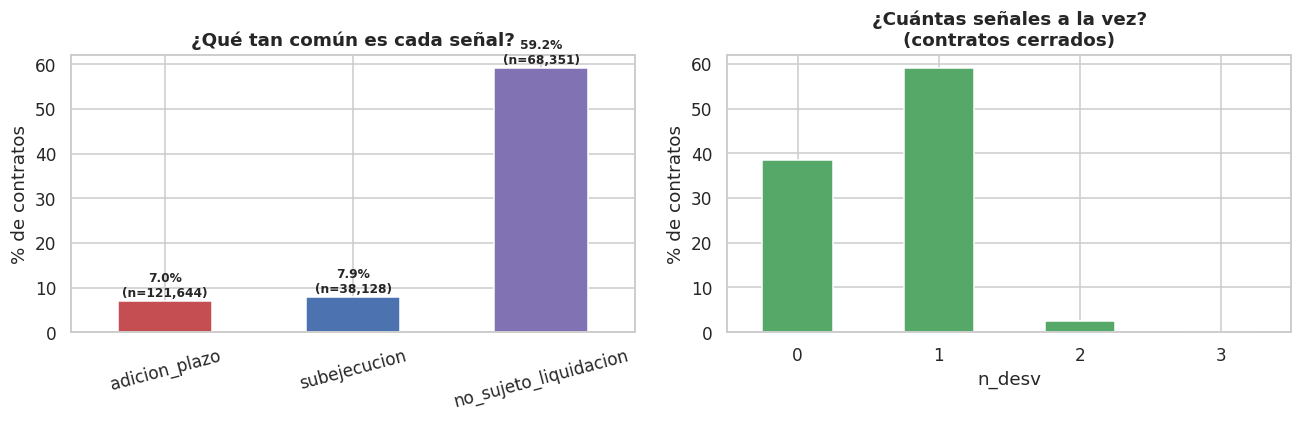

In [3]:
# Cada desviación se mide sobre su propia base (tienen denominadores distintos), así que las tasas
# no son directamente comparables entre sí; lo que importa aquí es el orden de magnitud de cada una.
com = base_liq.copy()
com['f_adic'] = com['adicion_plazo'].astype(int)
com['f_sub'] = com['subejecucion'].fillna(False).astype(int)
com['f_liq'] = com['no_sujeto_liquidacion'].astype(int)
com['n_desv'] = com[['f_adic', 'f_sub', 'f_liq']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tasas_glob = pd.Series({
    'adicion_plazo': base_adic['adicion_plazo'].mean(),
    'subejecucion': base_sub['subejecucion'].mean(),
    'no_sujeto_liquidacion': base_liq['no_sujeto_liquidacion'].mean(),
}) * 100
bases_n = {'adicion_plazo': len(base_adic), 'subejecucion': len(base_sub), 'no_sujeto_liquidacion': len(base_liq)}
tasas_glob.plot(kind='bar', ax=axes[0], color=['#C44E52', '#4C72B0', '#8172B3'])
axes[0].set_title('¿Qué tan común es cada señal?'); axes[0].set_ylabel('% de contratos'); axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(tasas_glob.items()):
    axes[0].text(i, v + 1, f'{v:.1f}%\n(n={bases_n[k]:,})', ha='center', fontsize=8, fontweight='bold')

com['n_desv'].value_counts(normalize=True).sort_index().mul(100).plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('¿Cuántas señales a la vez?\n(contratos cerrados)'); axes[1].set_ylabel('% de contratos'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_panorama.png', bbox_inches='tight'); plt.show()


Lo primero que salta: las tres señales son muy distintas de tamaño. Pedir más plazo y no ejecutar el presupuesto
son relativamente raras (~7–8%), mientras que **el 59% de los contratos cerrados no está marcado como sujeto a
liquidación**. Ojo: esa tercera señal no es una desviación de la ejecución, sino una característica que la entidad
declara al crear el contrato (ver 3.4). Además, una señal que aparece en 6 de cada 10 contratos no sirve para
*elegir a cuáles vigilar*, porque casi todos la tienen.

Conviene mirarlas por separado: como se ve en el segundo gráfico, la mayoría de los contratos tiene alguna señal
(casi siempre la falta de marca de liquidación), pero que coincidan las tres es raro.

### 3.2 Desviación 1 — Pedir más plazo (adiciones)

**Lo que esperamos:**
- **H1 (valor):** los contratos **más grandes** piden más plazo. *(H0: el valor es igual entre los que piden
  adición y los que no.)*
- **H2 (modalidad):** las modalidades **más competitivas y de mayor cuantía** (licitación, subasta) piden más
  plazo que la mínima cuantía. *(H0: la tasa de adición no depende de la modalidad.)*
- **H3 (destino):** la tasa de adición **depende del destino del gasto** (funcionamiento vs inversión).
- **H4 (PyME):** la tasa de adición **depende de si el proveedor es PyME**.


H1 — Valor del contrato (mediana en COP) según si tiene o no la señal:
  adicion_plazo         : con la señal=72,133,000  sin=28,850,000  -> los que la tienen valen MAYOR  (p=0.0e+00)
  subejecucion          : con la señal=54,803,795  sin=30,000,000  -> los que la tienen valen MAYOR  (p=7.4e-78)
  no_sujeto_liquidacion : con la señal=27,988,650  sin=42,150,000  -> los que la tienen valen MENOR  (p=5.4e-251)


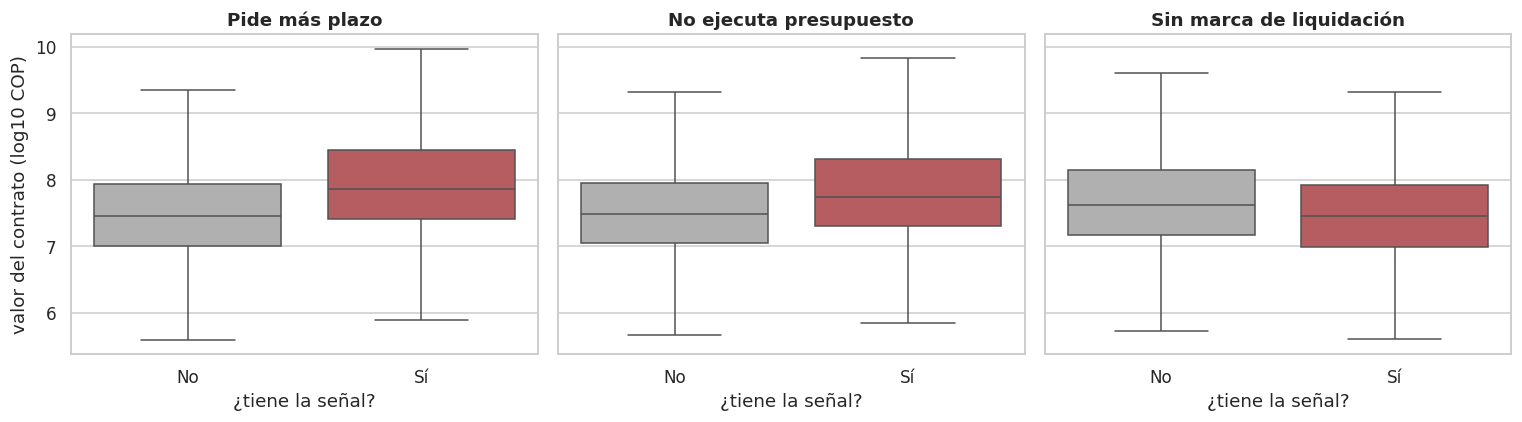

In [4]:
# H1: ¿los contratos con adición valen más? (lo miramos también en las otras dos desviaciones)
print('H1 — Valor del contrato (mediana en COP) según si tiene o no la señal:')
res_valor = {}
for flag, base in [('adicion_plazo', base_adic), ('subejecucion', base_sub), ('no_sujeto_liquidacion', base_liq)]:
    r = test_valor(base, flag); res_valor[flag] = r
    signo = 'MAYOR' if r['med_desv'] > r['med_no'] else 'MENOR'
    print(f'  {flag:22s}: con la señal={r["med_desv"]:,.0f}  sin={r["med_no"]:,.0f}  '
          f'-> los que la tienen valen {signo}  (p={r["p"]:.1e})')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (flag, base, titulo) in zip(axes, [
        ('adicion_plazo', base_adic, 'Pide más plazo'),
        ('subejecucion', base_sub, 'No ejecuta presupuesto'),
        ('no_sujeto_liquidacion', base_liq, 'Sin marca de liquidación')]):
    sub = base[base['valor_log'].notna()].copy(); sub[flag] = sub[flag].astype(bool)
    sns.boxplot(data=sub, x=flag, y='valor_log', hue=flag, legend=False, ax=ax,
                showfliers=False, palette={False: '#B0B0B0', True: '#C44E52'})
    ax.set_title(titulo); ax.set_xlabel('¿tiene la señal?'); ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Sí'])
axes[0].set_ylabel('valor del contrato (log10 COP)')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h1_valor.png', bbox_inches='tight'); plt.show()


Los datos le dan la razón a H1, y lo interesante es que **el valor no siempre apunta en la misma
dirección**: los contratos que piden más plazo y los que no ejecutan el presupuesto tienden a ser los **grandes**,
pero los que **no están marcados como sujetos a liquidación** son más bien los **pequeños**, lo esperable si
muchos son compras de entrega única, que no necesitan un corte de cuentas final. O sea, el valor sí ayuda a focalizar, pero
el "de qué lado poner el umbral" cambia según la señal que preocupe. Las tres comparaciones son
significativas (p muy por debajo de 0.001).


In [5]:
# H2-H4: modalidad, destino y PyME vs adición de plazo
for h, cat in [('H2', 'modalidad_de_contratacion'), ('H3', 'destino_gasto'), ('H4', 'es_pyme')]:
    r = test_categorica(base_adic, 'adicion_plazo', cat)
    print(f'{h}  adición vs {cat}:  p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"relación significativa" if r["sig"] else "SIN relación significativa"}')


H2  adición vs modalidad_de_contratacion:  p=0.00e+00  V=0.117 (pequeño)  -> relación significativa
H3  adición vs destino_gasto:  p=2.89e-105  V=0.063 (pequeño)  -> relación significativa
H4  adición vs es_pyme:  p=4.80e-01  V=0.002 (nulo)  -> SIN relación significativa


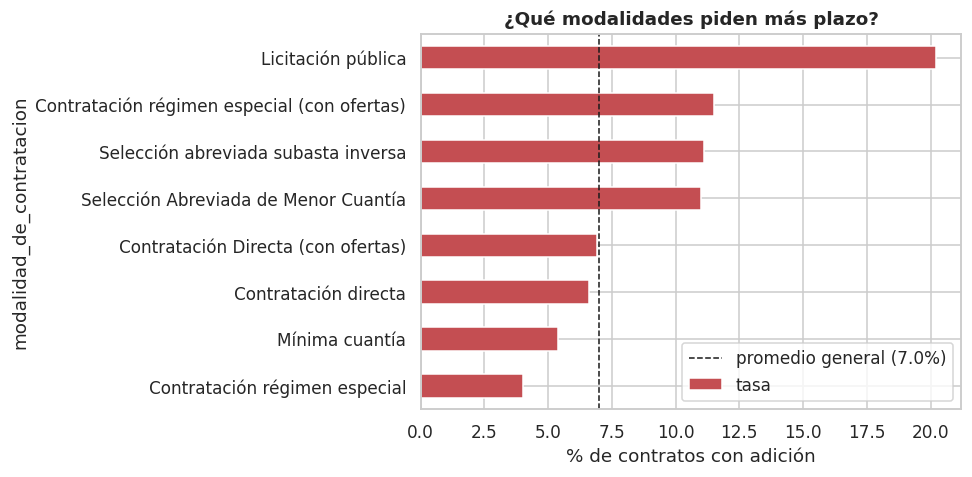

,tasa,n
modalidad_de_contratacion,,
Licitación pública,20.200,1615
Contratación régimen especial (con ofertas),11.500,3824
Selección abreviada subasta inversa,11.100,20449
Selección Abreviada de Menor Cuantía,11.000,5992
Contratación Directa (con ofertas),6.900,3421
Contratación directa,6.600,2700
Mínima cuantía,5.400,74032
Contratación régimen especial,4.000,9425


In [6]:
# Tasa de adición por modalidad (es la palanca de mayor efecto para esta desviación)
rH2 = test_categorica(base_adic, 'adicion_plazo', 'modalidad_de_contratacion')
tasa_global_adic = base_adic['adicion_plazo'].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
rH2['tasas']['tasa'].sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.axvline(tasa_global_adic, color='k', ls='--', lw=1, label=f'promedio general ({tasa_global_adic:.1f}%)')
ax.set_title('¿Qué modalidades piden más plazo?'); ax.set_xlabel('% de contratos con adición'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h2_modalidad.png', bbox_inches='tight'); plt.show()
rH2['tasas']


In [7]:
# Cifras concretas para citar (se calculan, no se escriben a mano)
tas = rH2['tasas']['tasa']
r_lic = tas.get('Licitación pública', float('nan'))
r_min = tas.get('Mínima cuantía', float('nan'))
print(f'Licitación pública: {r_lic:.1f}% de adición  |  Mínima cuantía: {r_min:.1f}%  |  promedio general: {tasa_global_adic:.1f}%')


Licitación pública: 20.2% de adición  |  Mínima cuantía: 5.4%  |  promedio general: 7.0%


**Adiciones de plazo — qué encontramos:**

- **H1 (valor): confirmada.** Los que piden adición valen bastante más (ver el boxplot). El valor es una señal
  temprana de riesgo.
- **H2 (modalidad): confirmada**, y es la palanca de mayor efecto aquí (V ≈ 0.12). La **licitación pública** es
  la que más pide plazo (~20%), muy por encima de la **mínima cuantía** (~5%), que es la más común. Tiene lógica:
  los procesos competitivos y de mayor cuantía son contratos más complejos, más propensos a alargarse. *(Las
  cifras exactas salen de la celda anterior, para que no se desactualicen.)*
- **H3 (destino): confirmada**, aunque con efecto chico: los contratos de **inversión** piden más plazo que los
  de **funcionamiento**.
- **H4 (PyME): no se confirma.** Que el proveedor sea PyME no cambia la tasa de adición (p > 0.05). Es decir, el
  tamaño del proveedor **no** sirve para esta desviación.


### 3.3 Desviación 2 — No ejecutar el presupuesto

**Lo que esperamos:**
- **H5 (tipo de contrato):** los **suministros** no ejecutan el presupuesto más que las **compraventas**.
  *(H0: la subejecución no depende del tipo.)* De paso miramos el **destino del gasto** como palanca de apoyo.

Recordatorio de `01`–`02`: como el campo `valor_pagado` viene muy subreportado, medimos la subejecución con
`valor_facturado` y solo sobre contratos que ya cerraron y que **sí reportaron ejecución**. Los que cerraron
reportando ejecución en cero (44% de los cerrados) los apartamos; más abajo probamos qué tan sensible es la
conclusión a ese supuesto.


H5  subejección vs tipo de contrato:  p=0.0e+00  V=0.196 (moderado) -> significativa
    subejección vs destino:          p=1.5e-68  V=0.091 (pequeño) -> significativa


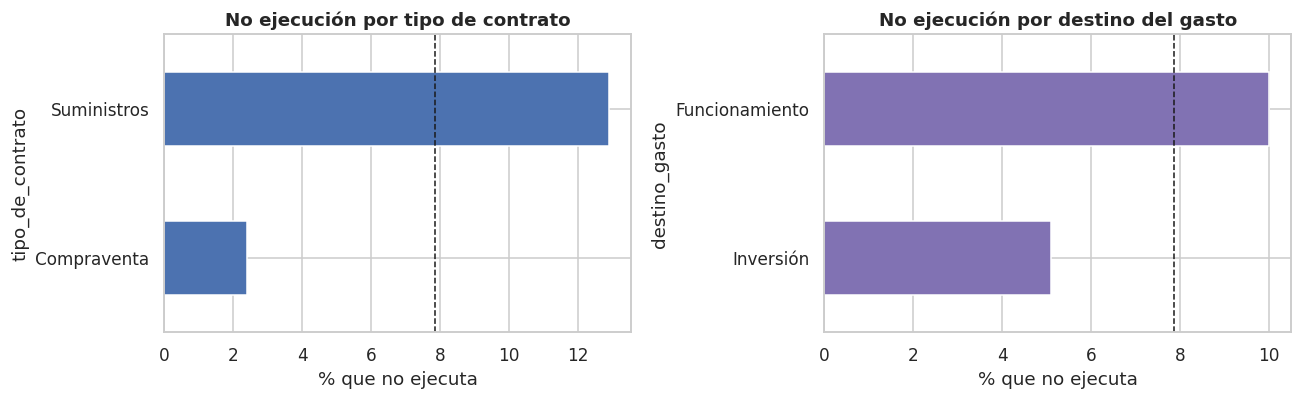

In [8]:
r5 = test_categorica(base_sub, 'subejecucion', 'tipo_de_contrato')
print(f'H5  subejección vs tipo de contrato:  p={r5["p"]:.1e}  V={r5["V"]:.3f} ({r5["efecto"]}) -> {"significativa" if r5["sig"] else "no significativa"}')
rd = test_categorica(base_sub, 'subejecucion', 'destino_gasto')
print(f'    subejección vs destino:          p={rd["p"]:.1e}  V={rd["V"]:.3f} ({rd["efecto"]}) -> {"significativa" if rd["sig"] else "no significativa"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (cat, titulo, color) in zip(axes, [('tipo_de_contrato', 'tipo de contrato', '#4C72B0'),
                                           ('destino_gasto', 'destino del gasto', '#8172B3')]):
    t = test_categorica(base_sub, 'subejecucion', cat)['tasas']['tasa']
    t.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.axvline(base_sub['subejecucion'].mean()*100, color='k', ls='--', lw=1)
    ax.set_title(f'No ejecución por {titulo}'); ax.set_xlabel('% que no ejecuta')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h3_subejec.png', bbox_inches='tight'); plt.show()


In [9]:
# Sensibilidad: ¿y si los contratos con facturado=0 fueran no-ejecución real, no un problema de captura?
base_cerr = d[d['ciclo_cerrado'] & d['periodo_analisis'] & d['valor_del_contrato_clean'].notna()]
n_apart = int(base_cerr['sin_ejecucion_reportada'].sum())
n_sub = int(np.nansum(d.loc[base_cerr.index, 'subejecucion']))
tasa_baja = base_sub['subejecucion'].mean() * 100                       # supuesto actual (los apartamos)
tasa_alta = (n_sub + n_apart) / len(base_cerr) * 100                    # cota superior (los contamos)
print(f'Subejección estimada: entre {tasa_baja:.1f}% (excluyendo facturado=0) y {tasa_alta:.1f}% (contándolos como no-ejecución)')

# ¿Sigue Suministros por encima de Compraventa bajo el supuesto extremo?
alt = base_cerr.copy()
alt['sub_alt'] = (alt['subejecucion'] == True) | (alt['valor_facturado'] == 0)
por_tipo = (alt.groupby('tipo_de_contrato')['sub_alt'].mean() * 100).round(1)
print('Bajo el supuesto extremo, no-ejecución por tipo:'); print(por_tipo.to_string())


Subejección estimada: entre 7.9% (excluyendo facturado=0) y 48.5% (contándolos como no-ejecución)
Bajo el supuesto extremo, no-ejecución por tipo:
tipo_de_contrato
Compraventa   44.300
Suministros   52.200


**No ejecución del presupuesto — qué encontramos:**

- **H5 (tipo): confirmada, y es la palanca que más discrimina esta desviación** (V ≈ 0.20). Los **suministros**
  no ejecutan mucho más (~13%) que las **compraventas** (~2%). Tiene sentido: en un suministro se entrega por
  partes a lo largo del tiempo, y es fácil que al final no se gaste todo lo que se había reservado.
- **Destino:** el **funcionamiento** no ejecuta más (~10%) que la **inversión** (~5%).
- **Sensibilidad (el punto flojo, dicho de frente):** la subejecución "real" está entre ~8% (nuestro supuesto,
  que aparta los contratos con ejecución reportada en cero) y una cota alta si esos 44% fueran no-ejecución
  genuina. No sabemos con certeza cuál es. La buena noticia es que **la dirección de H5 se mantiene** aun en el
  escenario extremo (los suministros siguen por encima de las compraventas), así que la conclusión práctica es
  robusta aunque el número exacto no lo sea. Lo dejamos anotado como limitación.


### 3.4 Desviación 3 — Cerrar sin liquidar (lo que sí se puede medir)

**Por qué no se puede medir directamente.** El campo `liquidaci_n` no dice si el contrato se liquidó: según la
guía del SECOP II, la entidad marca al crear el contrato si le **aplica** la liquidación (diccionario de `01`,
sección 1.1). Para saber si se liquidó harían falta `fecha_inicio_liquidacion` y `fecha_fin_liquidacion`, que el
conjunto completo de SECOP II publica pero nuestro extracto no trae.

Lo que sí podemos analizar es **qué contratos se declaran sujetos a liquidación**, y eso tiene lectura de negocio:
la liquidación es el corte de cuentas final entre la entidad y el contratista, y por ley (art. 60 de la Ley 80 de
1993) deben liquidarse los contratos de **tracto sucesivo**, como los suministros. El régimen especial no está
obligado por esa norma.

**Lo que esperamos:**
- **H6 (sector):** la proporción de contratos **sin marca** de liquidación **depende del sector**.
- **H7 (orden):** las entidades **territoriales** marcan menos contratos como sujetos a liquidación que las
  **nacionales**.

Como la señal aparece en la mayoría de los contratos cerrados, no sirve para elegir contratos uno a uno; buscamos
entender **dónde se concentra** y **qué la explica**.

H6  sin marca vs sector: p=0.0e+00  V=0.316 (fuerte) -> significativa
H7  sin marca vs orden:  p=3.7e-277  V=0.136 (pequeño) -> significativa


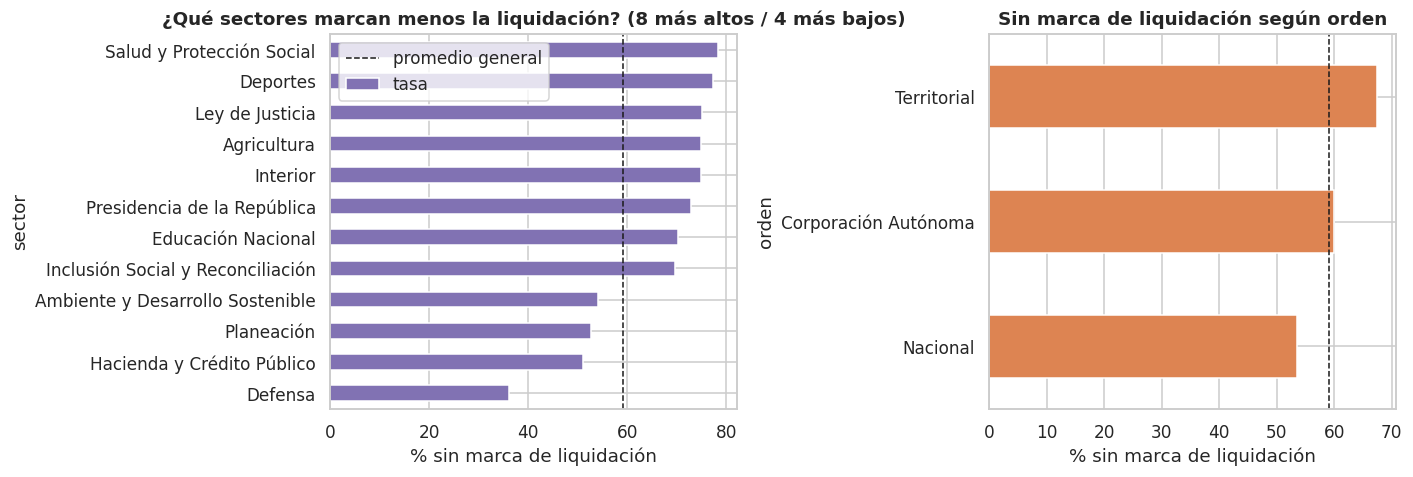

In [10]:
rs = test_categorica(base_liq, 'no_sujeto_liquidacion', 'sector')
ro = test_categorica(base_liq, 'no_sujeto_liquidacion', 'orden')
print(f'H6  sin marca vs sector: p={rs["p"]:.1e}  V={rs["V"]:.3f} ({rs["efecto"]}) -> {"significativa" if rs["sig"] else "no significativa"}')
print(f'H7  sin marca vs orden:  p={ro["p"]:.1e}  V={ro["V"]:.3f} ({ro["efecto"]}) -> {"significativa" if ro["sig"] else "no significativa"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top = pd.concat([rs['tasas'].head(8), rs['tasas'].tail(4)])
top['tasa'].sort_values().plot(kind='barh', ax=axes[0], color='#8172B3')
axes[0].axvline(base_liq['no_sujeto_liquidacion'].mean()*100, color='k', ls='--', lw=1, label='promedio general')
axes[0].set_title('¿Qué sectores marcan menos la liquidación? (8 más altos / 4 más bajos)'); axes[0].set_xlabel('% sin marca de liquidación'); axes[0].legend()
ro['tasas']['tasa'].sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].axvline(base_liq['no_sujeto_liquidacion'].mean()*100, color='k', ls='--', lw=1)
axes[1].set_title('Sin marca de liquidación según orden'); axes[1].set_xlabel('% sin marca de liquidación')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h4_sector_orden.png', bbox_inches='tight'); plt.show()


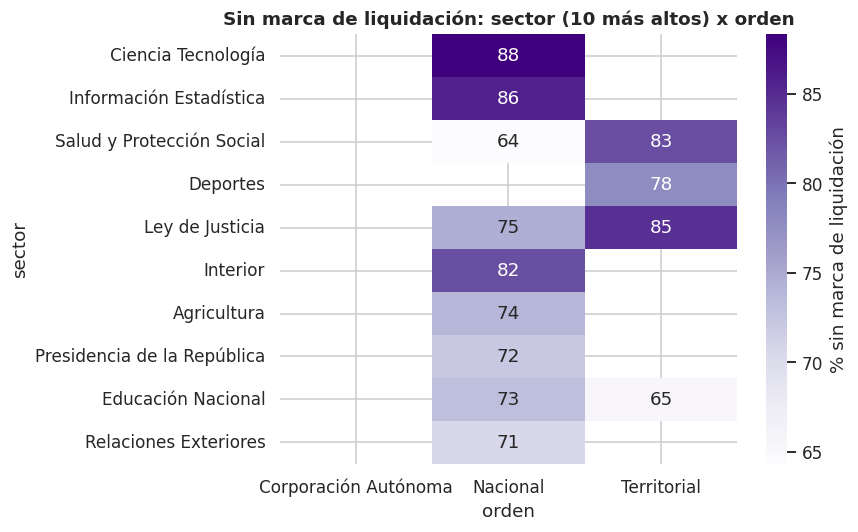

In [11]:
# Mapa de calor: contratos sin marca de liquidación por sector (10 más altos) x orden.
# Nos sirve para separar el peso del sector del peso del orden: si miramos solo una columna de orden,
# ¿siguen variando los sectores? Si sí, el sector dice algo por sí mismo.
sub = base_liq.copy(); sub['no_sujeto_liquidacion'] = sub['no_sujeto_liquidacion'].astype(bool)
piv = sub.pivot_table(index='sector', columns='orden', values='no_sujeto_liquidacion', aggfunc='mean') * 100
cnt = sub.pivot_table(index='sector', columns='orden', values='no_sujeto_liquidacion', aggfunc='size')
piv = piv.mask(cnt < 100)
orden_sec = sub.groupby('sector')['no_sujeto_liquidacion'].mean().sort_values(ascending=False).head(10).index
piv = piv.loc[[s for s in orden_sec if s in piv.index]]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='Purples', ax=ax, cbar_kws={'label': '% sin marca de liquidación'})
ax.set_title('Sin marca de liquidación: sector (10 más altos) x orden')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h4_heatmap.png', bbox_inches='tight'); plt.show()


% sin marca de liquidación, por régimen y tipo de contrato:
tipo_de_contrato  Compraventa  Suministros
regimen_especial                          
Estatuto general       61.200       51.800
Régimen especial       82.900       80.200

Contratos de régimen especial: 65% en Salud vs 4% en el resto

Suministros cerrados del estatuto general sin marca de liquidación: 15,686 (51.8%)
orden
Corporación Autónoma   46.100
Nacional               44.100
Territorial            63.000


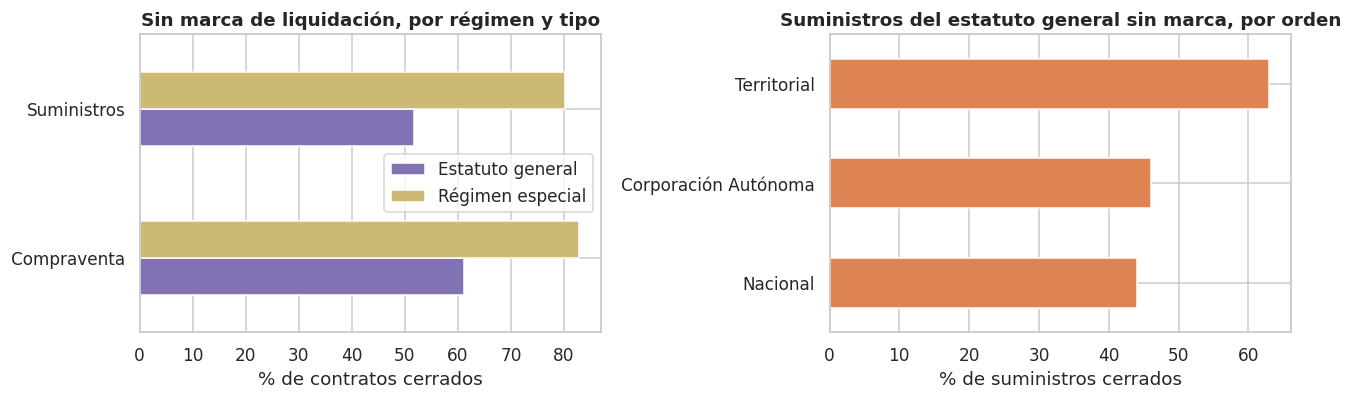

In [12]:
# ¿Qué explica la señal? El régimen especial no está obligado por la Ley 80 a liquidar, y los
# suministros (tracto sucesivo) por lo general sí deben liquidarse.
liq = base_liq.copy()
liq['sin_marca'] = liq['no_sujeto_liquidacion'].astype(bool)
liq['regimen_especial'] = liq['modalidad_de_contratacion'].str.contains('régimen especial', case=False)

tabla_reg = (liq.pivot_table(index='regimen_especial', columns='tipo_de_contrato', values='sin_marca',
                             aggfunc='mean') * 100).round(1)
tabla_reg.index = tabla_reg.index.map({False: 'Estatuto general', True: 'Régimen especial'})
print('% sin marca de liquidación, por régimen y tipo de contrato:'); print(tabla_reg.to_string())
salud = liq['sector'] == 'Salud y Protección Social'
print(f"\nContratos de régimen especial: {liq.loc[salud, 'regimen_especial'].mean() * 100:.0f}% en Salud vs "
      f"{liq.loc[~salud, 'regimen_especial'].mean() * 100:.0f}% en el resto")

sum_eg = liq[(liq['tipo_de_contrato'] == 'Suministros') & ~liq['regimen_especial']]
print(f"\nSuministros cerrados del estatuto general sin marca de liquidación: {sum_eg['sin_marca'].sum():,} "
      f"({sum_eg['sin_marca'].mean() * 100:.1f}%)")
por_orden = (sum_eg.groupby('orden')['sin_marca'].mean() * 100).round(1)
print(por_orden.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
tabla_reg.T.plot(kind='barh', ax=axes[0], color=['#8172B3', '#CCB974'])
axes[0].set_title('Sin marca de liquidación, por régimen y tipo'); axes[0].set_xlabel('% de contratos cerrados')
axes[0].set_ylabel(''); axes[0].legend(title='')
por_orden.sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Suministros del estatuto general sin marca, por orden')
axes[1].set_xlabel('% de suministros cerrados'); axes[1].set_ylabel('')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_h4_regimen.png', bbox_inches='tight'); plt.show()

**Contratos sin marca de liquidación — qué encontramos:**

- **H6 (sector): confirmada**, y es la relación más fuerte del análisis (V ≈ 0.32). **Salud y Protección Social**
  ronda el 78% de contratos sin marca, frente a **Defensa** (~36%). El mapa de calor muestra que las diferencias
  entre sectores siguen ahí al mirar un solo orden.
- **H7 (orden): confirmada.** Las entidades **territoriales** tienen más contratos sin marca (~67%) que las
  **nacionales** (~54%).
- **Buena parte se explica por el régimen jurídico.** El régimen especial, que no está obligado a liquidar por la
  Ley 80, deja sin marca a unos 8 de cada 10 contratos, y en Salud dos tercios de los contratos son de régimen
  especial (celda anterior). El 78% de Salud dice más sobre cómo contrata el sector que sobre una falla.
- **Lo que sí preocupa: los suministros del estatuto general.** Por ser de tracto sucesivo, por lo general deben
  liquidarse, y aun así más de la mitad de los cerrados no está marcada como sujeta a liquidación, con más peso en
  las entidades territoriales. O la marca se registra mal, o hay contratos que se cierran sin el corte de cuentas
  que exige la ley. Con este extracto no se puede distinguir entre las dos.

**La lectura importante:** esta señal no mide una desviación de la ejecución, sino **cómo se registra la
obligación de liquidar**. No sirve para elegir contratos uno a uno, pero sí señala un punto de revisión concreto:
los suministros del estatuto general sin marca de liquidación, empezando por las entidades territoriales.

### 3.5 Un contraste que buscábamos que fallara — el tamaño del proveedor (PyME)

Incluimos a propósito una hipótesis que esperábamos **no** confirmar, para mostrar qué **no** ayuda a focalizar.

> **H8.** Ser **PyME** no distingue a los contratos que se desvían. *(H0: la tasa de desviación no depende de
> `es_pyme`; aquí esperamos **no** poder rechazar H0.)*


In [13]:
print('H8 — es_pyme vs cada señal:')
for flag, base in [('adicion_plazo', base_adic), ('subejecucion', base_sub), ('no_sujeto_liquidacion', base_liq)]:
    r = test_categorica(base, flag, 'es_pyme')
    print(f'  {flag:22s}: p={r["p"]:.2e}  V={r["V"]:.3f} ({r["efecto"]})  '
          f'-> {"significativa" if r["sig"] else "NO significativa"}')


H8 — es_pyme vs cada señal:
  adicion_plazo         : p=4.80e-01  V=0.002 (nulo)  -> NO significativa
  subejecucion          : p=5.10e-68  V=0.089 (pequeño)  -> significativa
  no_sujeto_liquidacion : p=5.25e-02  V=0.007 (nulo)  -> NO significativa


**Como esperábamos, PyME no ayuda.** No cambia la tasa de adiciones (p ≈ 0.48) ni la de contratos sin marca
de liquidación (p ≈ 0.05, al filo); y aunque en subejecución sí sale significativa, el efecto es tan chico (V ≈ 0.09) que en la
práctica no distingue. Conclusión: **no vale la pena priorizar la supervisión por el tamaño del proveedor.** Este
es un resultado "negativo", y lo reportamos igual porque también informa la decisión.


### 3.6 Juntando las piezas: segmentos de alto riesgo para el triage

Hasta acá miramos las palancas de a una. Pero el equipo de control interno no ve una variable a la vez: ve un
contrato con **todas** sus características juntas. Así que combinamos las señales que sí sirven para elegir —las
dos desviaciones raras, **pedir más plazo** y **no ejecutar el presupuesto**— en una sola marca de "conviene
mirarlo" (`triage`), y vemos qué **combinaciones** de características concentran más riesgo.

Dejamos fuera la marca de liquidación a propósito: no es una desviación de la ejecución, sino una característica
que se declara al firmar (3.4), y como la tiene la mayoría, mezclarla no ayudaría a priorizar.


In [14]:
seg = base_liq.copy()   # contratos cerrados y en periodo (donde las dos señales están definidas)
# 'triage' = pidió más plazo O no ejecutó el presupuesto (subejec NaN no cuenta como desviación)
seg['triage'] = seg['adicion_plazo'].astype(bool) | (seg['subejecucion'] == True)

# Agrupamos la modalidad en 3 familias para que los segmentos sean legibles
COMPETITIVAS = ['Licitación pública', 'Selección abreviada subasta inversa',
                'Selección Abreviada de Menor Cuantía', 'Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes',
                'Contratación régimen especial (con ofertas)']
def familia_modalidad(m):
    if m == 'Mínima cuantía': return 'Mínima cuantía'
    if m in COMPETITIVAS: return 'Competitiva / mayor cuantía'
    return 'Otras (directa / régimen especial)'
seg['modalidad_familia'] = seg['modalidad_de_contratacion'].map(familia_modalidad)

tasa_triage = seg['triage'].mean() * 100
tabla_seg = seg.groupby(['tipo_de_contrato', 'destino_gasto', 'modalidad_familia'])['triage'].agg(tasa='mean', n='size')
tabla_seg = tabla_seg[tabla_seg['n'] >= 300].sort_values('tasa', ascending=False)
tabla_seg['tasa'] = (tabla_seg['tasa'] * 100).round(1)
tabla_seg['lift_vs_promedio'] = (tabla_seg['tasa'] / tasa_triage).round(2)
print(f'De cada 100 contratos cerrados, {tasa_triage:.1f} tienen al menos una de las dos desviaciones de triage.')
print('Segmentos ordenados de mayor a menor riesgo (min. 300 contratos):')
tabla_seg


De cada 100 contratos cerrados, 4.7 tienen al menos una de las dos desviaciones de triage.
Segmentos ordenados de mayor a menor riesgo (min. 300 contratos):


tasa      n  lift_vs_promedio
tipo_de_contrato destino_gasto  modalidad_familia                                                
Suministros      Funcionamiento Competitiva / mayor cuantía        9.600   7013             2.050
                                Mínima cuantía                     7.700  13043             1.640
                 Inversión      Competitiva / mayor cuantía        7.300   3923             1.560
                                Otras (directa / régimen especial) 6.900    937             1.470
                 Funcionamiento Otras (directa / régimen especial) 6.200   4194             1.320
                 Inversión      Mínima cuantía                     5.400   6628             1.150
Compraventa      Funcionamiento Competitiva / mayor cuantía        2.700   3987             0.580
                 Inversión      Competitiva / mayor cuantía        2.100   4113             0.450
                                Otras (directa / régimen especial) 1.900   1200             0.410
                 Funcionamiento Otras (directa / régimen especial) 1.500   1947             0.320
                                Mínima cuantía                     1.500  12987             0.320
                 Inversión      Mínima cuantía                     1.200   7971             0.260

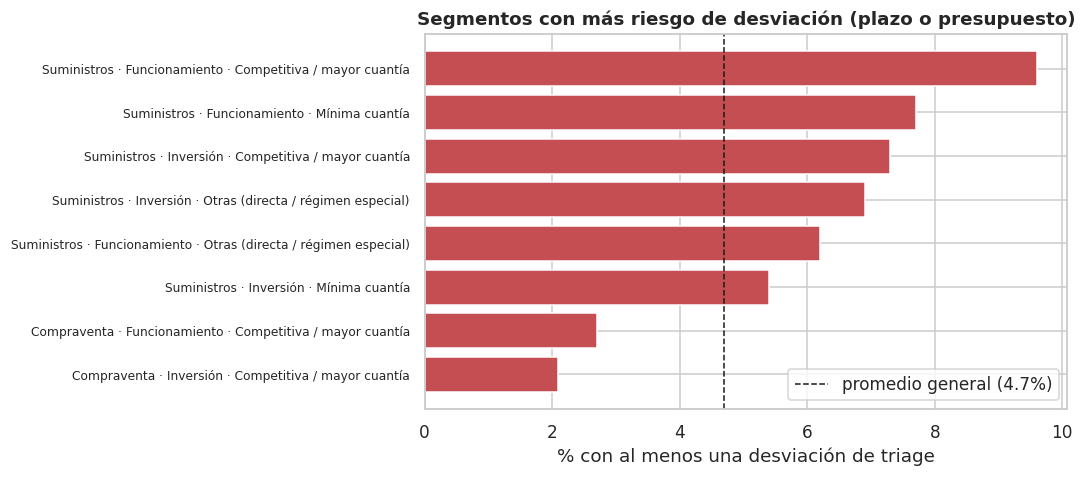

In [15]:
# Los 8 segmentos de mayor riesgo, para verlos de un vistazo
top_seg = tabla_seg.head(8).copy()
etiquetas = [f'{t} · {d} · {m}' for (t, d, m) in top_seg.index]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(range(len(top_seg)), top_seg['tasa'].values[::-1], color='#C44E52')
ax.set_yticks(range(len(top_seg))); ax.set_yticklabels(etiquetas[::-1], fontsize=8)
ax.axvline(tasa_triage, color='k', ls='--', lw=1, label=f'promedio general ({tasa_triage:.1f}%)')
ax.set_title('Segmentos con más riesgo de desviación (plazo o presupuesto)')
ax.set_xlabel('% con al menos una desviación de triage'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_segmentos_riesgo.png', bbox_inches='tight'); plt.show()


Esta tabla es el **puente hacia las recomendaciones**: en vez de decir "el sector importa" o "el tipo
importa" por separado, muestra **qué combinaciones concretas** concentran el riesgo. Los segmentos de arriba
—típicamente **suministros**, de **funcionamiento**, en modalidades **competitivas / de mayor cuantía**— tienen
tasas de desviación de hasta el **doble** del promedio (columna `lift_vs_promedio`), mientras que abajo quedan
combinaciones de bajo riesgo que casi no vale la pena vigilar. Es exactamente la clase de regla que control
interno puede aplicar al ver un contrato recién firmado. En el informe ejecutivo (Entregable 4) traducimos estos
segmentos en criterios de focalización priorizados.


### 3.7 Resumen de las hipótesis

In [16]:
tas = rH2['tasas']['tasa']
filas = [
    ['H1', 'Más plazo ~ valor', 'Mann-Whitney', 'Confirmada',
     'los que piden adición valen más (p<0.001)'],
    ['H2', 'Más plazo ~ modalidad', 'χ²', 'Confirmada',
     f'V={rH2["V"]:.3f}; Licitación {tas.get("Licitación pública", float("nan")):.1f}% vs Mínima cuantía {tas.get("Mínima cuantía", float("nan")):.1f}%'],
    ['H3', 'Más plazo ~ destino', 'χ²', 'Confirmada (efecto chico)',
     f'V={test_categorica(base_adic,"adicion_plazo","destino_gasto")["V"]:.3f}; inversión > funcionamiento'],
    ['H4', 'Más plazo ~ PyME', 'χ²', 'NO se confirma',
     f'p={test_categorica(base_adic,"adicion_plazo","es_pyme")["p"]:.2f} (sin relación)'],
    ['H5', 'No ejecuta ~ tipo (y destino)', 'χ²', 'Confirmada',
     f'V={r5["V"]:.3f}; Suministros ~13% vs Compraventa ~2%'],
    ['H6', 'Sin marca de liquidación ~ sector', 'χ²', 'Confirmada (en buena parte, por el régimen especial)',
     f'V={rs["V"]:.3f}; Salud ~78% vs Defensa ~36%'],
    ['H7', 'Sin marca de liquidación ~ orden', 'χ²', 'Confirmada',
     f'V={ro["V"]:.3f}; Territorial ~67% vs Nacional ~54%'],
    ['H8', 'Cualquier señal ~ PyME (nula)', 'χ²', 'No se rechaza H0 (como esperábamos)',
     'sin efecto práctico (V≈0 a 0.09)'],
]
resumen = pd.DataFrame(filas, columns=['H', 'Hipótesis', 'Prueba', 'Veredicto', 'En corto'])
resumen


,H,Hipótesis,Prueba,Veredicto,En corto
0,H1,Más plazo ~ valor,Mann-Whitney,Confirmada,los que piden adición valen más (p<0.001)
1,H2,Más plazo ~ modalidad,χ²,Confirmada,V=0.117; Licitación 20.2% vs Mínima cuantía 5.4%
2,H3,Más plazo ~ destino,χ²,Confirmada (efecto chico),V=0.063; inversión > funcionamiento
3,H4,Más plazo ~ PyME,χ²,NO se confirma,p=0.48 (sin relación)
4,H5,No ejecuta ~ tipo (y destino),χ²,Confirmada,V=0.196; Suministros ~13% vs Compraventa ~2%
5,H6,Sin marca de liquidación ~ sector,χ²,"Confirmada (en buena parte, por el régimen esp...",V=0.316; Salud ~78% vs Defensa ~36%
6,H7,Sin marca de liquidación ~ orden,χ²,Confirmada,V=0.136; Territorial ~67% vs Nacional ~54%
7,H8,Cualquier señal ~ PyME (nula),χ²,No se rechaza H0 (como esperábamos),sin efecto práctico (V≈0 a 0.09)


## 4. Lo que nos llevamos (insights)

1. **El valor del contrato avisa temprano, pero hay que leerlo con cuidado:** los contratos **grandes** tienden
   a pedir más plazo y a no ejecutar el presupuesto; los **pequeños** se declaran menos sujetos a liquidación. Un umbral de valor
   sirve para focalizar, siempre que se mire en la dirección correcta.
2. **La modalidad marca las adiciones de plazo:** licitación pública y selecciones abreviadas se alargan mucho
   más que la mínima cuantía.
3. **El tipo de contrato es la mejor pista para la no-ejecución:** los suministros dejan plata sin ejecutar
   mucho más que las compraventas.
4. **Cerrar sin liquidar no se puede medir con estos datos, pero el registro de la liquidación deja una pista:**
   el ~59% de los cerrados no está marcado como sujeto a liquidación. Buena parte se explica por el régimen
   especial, que no está obligado a liquidar, pero más de la mitad de los suministros del estatuto general (que por
   lo general sí deben liquidarse) tampoco lo está, sobre todo en entidades territoriales. Es un punto de revisión
   del registro, no un criterio para vigilar contratos uno a uno.
5. **El tamaño del proveedor (PyME) no ayuda a focalizar:** es un resultado negativo, y por eso mismo útil —evita
   gastar esfuerzo en un criterio que no distingue.
6. **Juntando las señales que sí sirven** (plazo + presupuesto), aparecen **segmentos concretos de alto riesgo**
   (suministros de funcionamiento en modalidades de mayor cuantía), con tasas de hasta el doble del promedio.

> **Una advertencia honesta.** Todo esto es análisis **bivariado/descriptivo**: mira las señales de a una (o, en la
> tabla de segmentos, combinadas de forma simple), pero no aísla el efecto de cada variable controlando por las
> demás; para eso haría falta un modelo, que queda fuera del alcance. Además, la subejecución depende de un
> supuesto sobre datos de ejecución faltantes (ver la sensibilidad en 3.3), y la desviación "cerrar sin liquidar"
> no se puede medir porque el extracto no trae las fechas de liquidación (3.4). Lo tenemos en cuenta al recomendar.

**Siguiente paso:** el informe ejecutivo (Entregable 4) convierte los segmentos de alto riesgo en criterios de
focalización priorizados, con sus limitaciones.
